PC1 解釋變異量: 26.84%
PC2 解釋變異量: 20.65%
總共解釋變異量: 47.48%


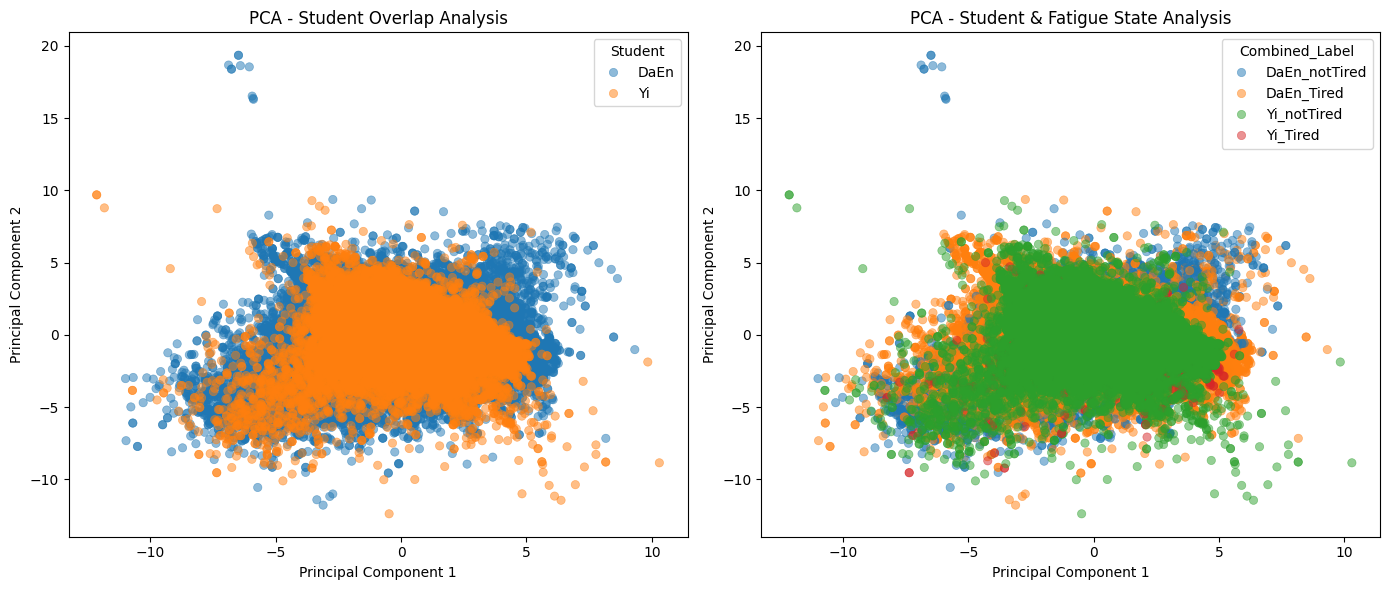

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 定義資料讀取函數
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    
    # 檢查路徑是否存在
    if not os.path.exists(folder_path):
        print(f"警告：找不到路徑 {folder_path}")
        return pd.DataFrame()
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            
            # 讀取 CSV
            df = pd.read_csv(file_path)
            
            # 判斷疲勞狀態 (根據檔名關鍵字)
            if 'notTired' in file_name:
                state_label = 'notTired'
            elif 'Tired' in file_name:
                state_label = 'Tired'
            else:
                continue # 如果檔名沒有關鍵字則跳過
            
            # 新增標籤欄位
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            
            combined_data.append(df)
            
    if combined_data:
        return pd.concat(combined_data, ignore_index=True)
    else:
        return pd.DataFrame()

# ==========================================
# 2. 載入與整合數據
# ==========================================
# 請將下方的路徑替換為您電腦中的實際路徑
path_A = '../data_v58/test_data' 
path_B = './test_data_hengling_yi'

df_A = load_data_from_folder(path_A, 'DaEn')
df_B = load_data_from_folder(path_B, 'Yi')

# 合併 A、B 兩位同學的數據
df_all = pd.concat([df_A, df_B], ignore_index=True)

# 定義特徵欄位 (請根據您實際的 CSV 欄位名稱修改)
feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']

# 確保所有特徵欄位都存在
df_all = df_all.dropna(subset=feature_cols)
X = df_all[feature_cols]

# ==========================================
# 3. 資料標準化 (關鍵步驟！)
# ==========================================
# 加速度和陀螺儀的單位與數值範圍完全不同，必須標準化，否則 PCA 會被數值大的特徵主導
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. 執行 PCA 降維 (降至 2 維)
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 將 PCA 結果存回 DataFrame
df_all['PCA1'] = X_pca[:, 0]
df_all['PCA2'] = X_pca[:, 1]

# 印出解釋變異量 (Explained Variance Ratio)
print(f"PC1 解釋變異量: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 解釋變異量: {pca.explained_variance_ratio_[1]:.2%}")
print(f"總共解釋變異量: {sum(pca.explained_variance_ratio_):.2%}")

# ==========================================
# 5. 視覺化繪圖
# ==========================================
plt.figure(figsize=(14, 6))

# 圖一：觀察 A、B 兩位同學的特徵是否有重疊
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_all, x='PCA1', y='PCA2', hue='Student', alpha=0.5, edgecolor=None)
plt.title('PCA - Student Overlap Analysis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# 圖二：同時觀察同學與疲勞狀態的交叉影響
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_all, x='PCA1', y='PCA2', hue='Combined_Label', alpha=0.5, edgecolor=None)
plt.title('PCA - Student & Fatigue State Analysis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

PC1 解釋變異量: 27.79%
PC2 解釋變異量: 20.85%
總共解釋變異量: 48.64%


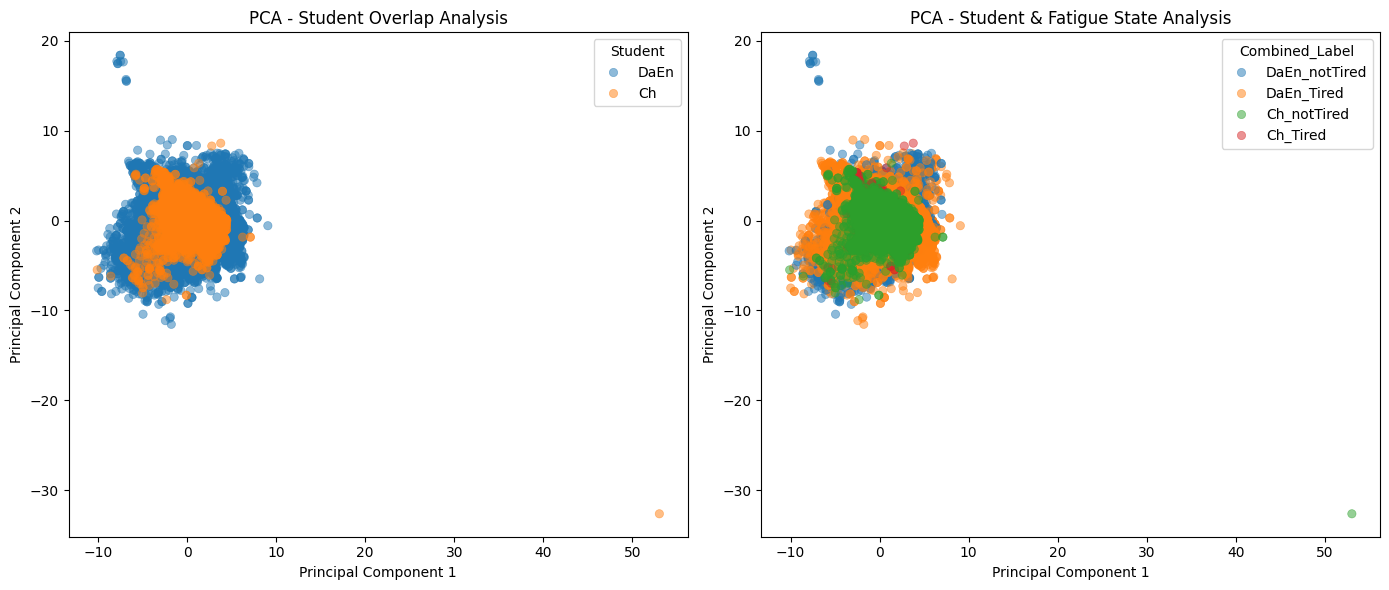

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 定義資料讀取函數
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    
    # 檢查路徑是否存在
    if not os.path.exists(folder_path):
        print(f"警告：找不到路徑 {folder_path}")
        return pd.DataFrame()
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            
            # 讀取 CSV
            df = pd.read_csv(file_path)
            
            # 判斷疲勞狀態 (根據檔名關鍵字)
            if 'notTired' in file_name:
                state_label = 'notTired'
            elif 'Tired' in file_name:
                state_label = 'Tired'
            else:
                continue # 如果檔名沒有關鍵字則跳過
            
            # 新增標籤欄位
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            
            combined_data.append(df)
            
    if combined_data:
        return pd.concat(combined_data, ignore_index=True)
    else:
        return pd.DataFrame()

# ==========================================
# 2. 載入與整合數據
# ==========================================
# 請將下方的路徑替換為您電腦中的實際路徑
path_A = '../data_v58/test_data' 
path_B = './test_data_6'

df_A = load_data_from_folder(path_A, 'DaEn')
df_B = load_data_from_folder(path_B, 'Ch')

# 合併 A、B 兩位同學的數據
df_all = pd.concat([df_A, df_B], ignore_index=True)

# 定義特徵欄位 (請根據您實際的 CSV 欄位名稱修改)
feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']

# 確保所有特徵欄位都存在
df_all = df_all.dropna(subset=feature_cols)
X = df_all[feature_cols]

# ==========================================
# 3. 資料標準化 (關鍵步驟！)
# ==========================================
# 加速度和陀螺儀的單位與數值範圍完全不同，必須標準化，否則 PCA 會被數值大的特徵主導
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. 執行 PCA 降維 (降至 2 維)
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 將 PCA 結果存回 DataFrame
df_all['PCA1'] = X_pca[:, 0]
df_all['PCA2'] = X_pca[:, 1]

# 印出解釋變異量 (Explained Variance Ratio)
print(f"PC1 解釋變異量: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 解釋變異量: {pca.explained_variance_ratio_[1]:.2%}")
print(f"總共解釋變異量: {sum(pca.explained_variance_ratio_):.2%}")

# ==========================================
# 5. 視覺化繪圖
# ==========================================
plt.figure(figsize=(14, 6))

# 圖一：觀察 A、B 兩位同學的特徵是否有重疊
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_all, x='PCA1', y='PCA2', hue='Student', alpha=0.5, edgecolor=None)
plt.title('PCA - Student Overlap Analysis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# 圖二：同時觀察同學與疲勞狀態的交叉影響
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_all, x='PCA1', y='PCA2', hue='Combined_Label', alpha=0.5, edgecolor=None)
plt.title('PCA - Student & Fatigue State Analysis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

PC1 解釋變異量: 26.84%
PC2 解釋變異量: 20.65%
PC3 解釋變異量: 17.94%
總共解釋變異量: 65.42%


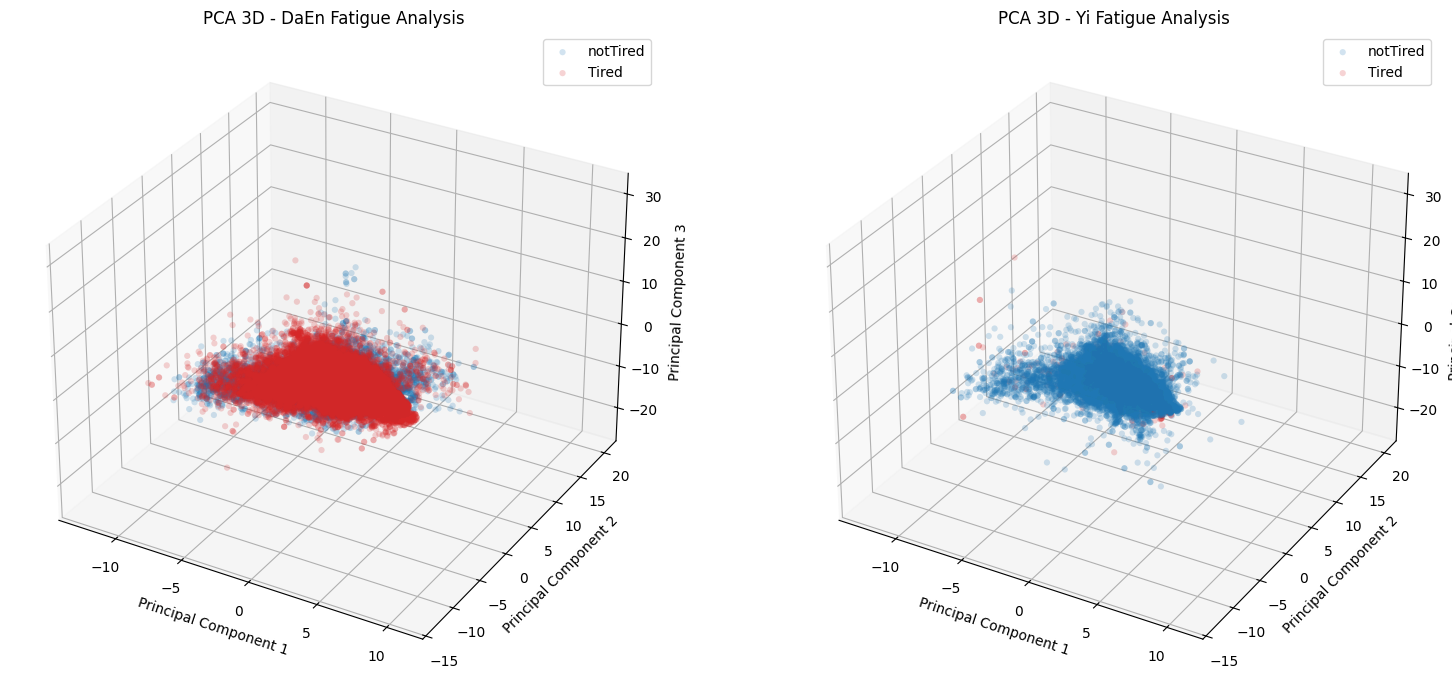

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 定義資料讀取函數
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    
    # 檢查路徑是否存在
    if not os.path.exists(folder_path):
        print(f"警告：找不到路徑 {folder_path}")
        return pd.DataFrame()
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            
            # 讀取 CSV
            df = pd.read_csv(file_path)
            
            # 判斷疲勞狀態 (根據檔名關鍵字)
            if 'notTired' in file_name:
                state_label = 'notTired'
            elif 'Tired' in file_name:
                state_label = 'Tired'
            else:
                continue # 如果檔名沒有關鍵字則跳過
            
            # 新增標籤欄位
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            
            combined_data.append(df)
            
    if combined_data:
        return pd.concat(combined_data, ignore_index=True)
    else:
        return pd.DataFrame()

# ==========================================
# 2. 載入與整合數據
# ==========================================
# 請將下方的路徑替換為您電腦中的實際路徑
path_A = '../data_v58/test_data' 
path_B = './test_data_hengling_yi'

df_A = load_data_from_folder(path_A, 'DaEn')
df_B = load_data_from_folder(path_B, 'Yi')

# 合併 A、B 兩位同學的數據
df_all = pd.concat([df_A, df_B], ignore_index=True)

# 定義特徵欄位
feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']

# 確保所有特徵欄位都存在
df_all = df_all.dropna(subset=feature_cols)
X = df_all[feature_cols]

# ==========================================
# 3. 資料標準化 (關鍵步驟！)
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. 執行 PCA 降維 (降至 3 維)
# ==========================================
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 將 PCA 結果存回 DataFrame
df_all['PCA1'] = X_pca[:, 0]
df_all['PCA2'] = X_pca[:, 1]
df_all['PCA3'] = X_pca[:, 2]

# 印出解釋變異量
print(f"PC1 解釋變異量: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 解釋變異量: {pca.explained_variance_ratio_[1]:.2%}")
print(f"PC3 解釋變異量: {pca.explained_variance_ratio_[2]:.2%}")
print(f"總共解釋變異量: {sum(pca.explained_variance_ratio_):.2%}")

# ==========================================
# 5. 計算統一的 3D 坐標軸範圍 (新加入步驟！)
# ==========================================
# 找出全體數據中三個主成分的極值
x_min, x_max = df_all['PCA1'].min(), df_all['PCA1'].max()
y_min, y_max = df_all['PCA2'].min(), df_all['PCA2'].max()
z_min, z_max = df_all['PCA3'].min(), df_all['PCA3'].max()

# 加上 10% 的邊界留白
x_margin = (x_max - x_min) * 0.1
y_margin = (y_max - y_min) * 0.1
z_margin = (z_max - z_min) * 0.1

xlim_set = (x_min - x_margin, x_max + x_margin)
ylim_set = (y_min - y_margin, y_max + y_margin)
zlim_set = (z_min - z_margin, z_max + z_margin)

# ==========================================
# 6. 視覺化繪圖 (固定所有 3D 軸)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': '3d'})

# 定義疲勞狀態與對應的顏色
state_colors = {'notTired': '#1f77b4', 'Tired': '#d62728'} 

# ------------------------------------------
# 圖一：單獨繪製 DaEn 的疲勞狀態分析
# ------------------------------------------
ax1 = axes[0]
df_daen = df_all[df_all['Student'] == 'DaEn']

for state_name, color in state_colors.items():
    group = df_daen[df_daen['State'] == state_name]
    if not group.empty:
        ax1.scatter(group['PCA1'], group['PCA2'], group['PCA3'], 
                    label=state_name, alpha=0.2, color=color, edgecolors='none')

ax1.set_title("PCA 3D - DaEn Fatigue Analysis")
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.set_zlabel('Principal Component 3')
ax1.legend()

# 強制對齊軸範圍
ax1.set_xlim3d(xlim_set)
ax1.set_ylim3d(ylim_set)
ax1.set_zlim3d(zlim_set)

# ------------------------------------------
# 圖二：單獨繪製 Yi 的疲勞狀態分析
# ------------------------------------------
ax2 = axes[1]
df_yi = df_all[df_all['Student'] == 'Yi']

for state_name, color in state_colors.items():
    group = df_yi[df_yi['State'] == state_name]
    if not group.empty:
        ax2.scatter(group['PCA1'], group['PCA2'], group['PCA3'], 
                    label=state_name, alpha=0.2, color=color, edgecolors='none')

ax2.set_title("PCA 3D - Yi Fatigue Analysis")
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_zlabel('Principal Component 3')
ax2.legend()

# 強制對齊軸範圍
ax2.set_xlim3d(xlim_set)
ax2.set_ylim3d(ylim_set)
ax2.set_zlim3d(zlim_set)

plt.tight_layout()
plt.show()

PC1 解釋變異量: 26.84%
PC2 解釋變異量: 20.65%
總共解釋變異量: 47.48%


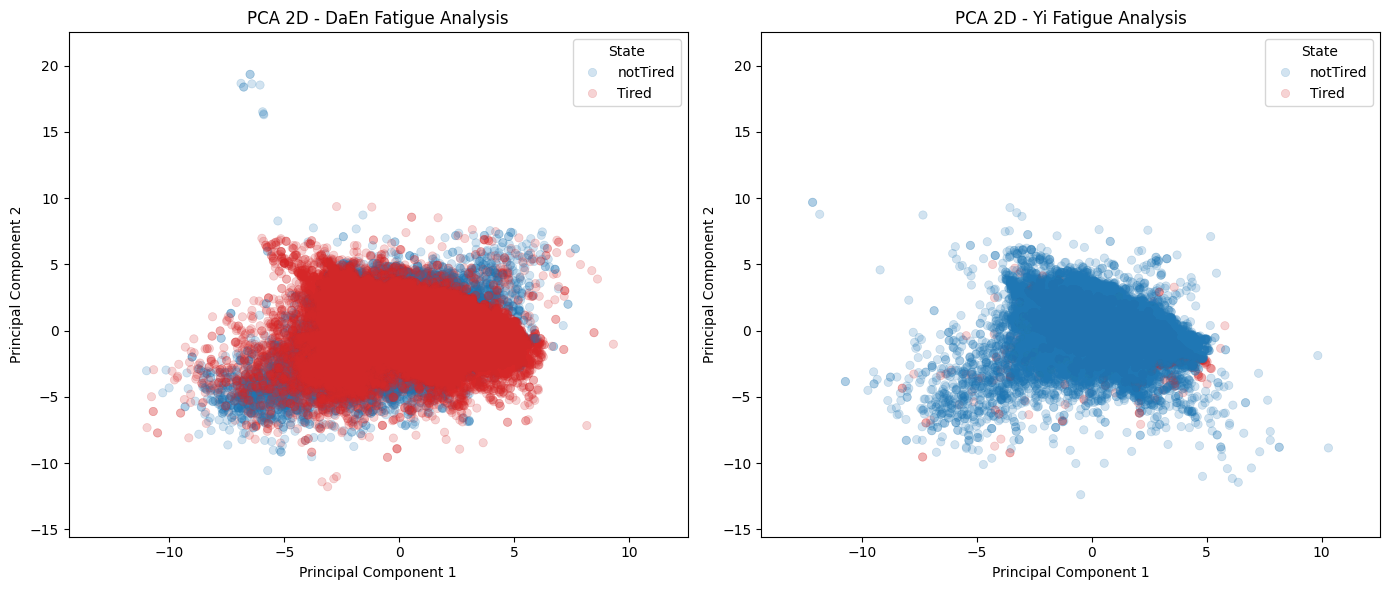

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 定義資料讀取函數
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    
    # 檢查路徑是否存在
    if not os.path.exists(folder_path):
        print(f"警告：找不到路徑 {folder_path}")
        return pd.DataFrame()
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            
            # 讀取 CSV
            df = pd.read_csv(file_path)
            
            # 判斷疲勞狀態 (根據檔名關鍵字)
            if 'notTired' in file_name:
                state_label = 'notTired'
            elif 'Tired' in file_name:
                state_label = 'Tired'
            else:
                continue # 如果檔名沒有關鍵字則跳過
            
            # 新增標籤欄位
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            
            combined_data.append(df)
            
    if combined_data:
        return pd.concat(combined_data, ignore_index=True)
    else:
        return pd.DataFrame()

# ==========================================
# 2. 載入與整合數據
# ==========================================
# 請將下方的路徑替換為您電腦中的實際路徑
path_A = '../data_v58/test_data' 
path_B = './test_data_hengling_yi'

df_A = load_data_from_folder(path_A, 'DaEn')
df_B = load_data_from_folder(path_B, 'Yi')

# 合併 A、B 兩位同學的數據
df_all = pd.concat([df_A, df_B], ignore_index=True)

# 定義特徵欄位
feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']

# 確保所有特徵欄位都存在
df_all = df_all.dropna(subset=feature_cols)
X = df_all[feature_cols]

# ==========================================
# 3. 資料標準化
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. 執行 PCA 降維
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 將 PCA 結果存回 DataFrame
df_all['PCA1'] = X_pca[:, 0]
df_all['PCA2'] = X_pca[:, 1]

# 印出解釋變異量
print(f"PC1 解釋變異量: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 解釋變異量: {pca.explained_variance_ratio_[1]:.2%}")
print(f"總共解釋變異量: {sum(pca.explained_variance_ratio_):.2%}")

# ==========================================
# 5. 計算統一的坐標軸範圍 (關鍵修改！)
# ==========================================
# 找出所有數據中 PCA1 與 PCA2 的極值
x_min, x_max = df_all['PCA1'].min(), df_all['PCA1'].max()
y_min, y_max = df_all['PCA2'].min(), df_all['PCA2'].max()

# 加上 10% 的邊界留白，避免數據點緊貼圖表邊緣
x_margin = (x_max - x_min) * 0.1
y_margin = (y_max - y_min) * 0.1

xlim_set = (x_min - x_margin, x_max + x_margin)
ylim_set = (y_min - y_margin, y_max + y_margin)

# ==========================================
# 6. 視覺化繪圖 (已固定坐標軸與調整透明度)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

custom_palette = {'notTired': '#1f77b4', 'Tired': '#d62728'}

# ------------------------------------------
# 圖一：單獨繪製 DaEn 的 2D 疲勞狀態分析
# ------------------------------------------
df_daen = df_all[df_all['Student'] == 'DaEn']
sns.scatterplot(
    data=df_daen, x='PCA1', y='PCA2', hue='State', 
    palette=custom_palette, alpha=0.2, edgecolor=None, ax=axes[0]
)
axes[0].set_title('PCA 2D - DaEn Fatigue Analysis')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# 套用統一的軸範圍
axes[0].set_xlim(xlim_set)
axes[0].set_ylim(ylim_set)

# ------------------------------------------
# 圖二：單獨繪製 Yi 的 2D 疲勞狀態分析
# ------------------------------------------
df_yi = df_all[df_all['Student'] == 'Yi']
sns.scatterplot(
    data=df_yi, x='PCA1', y='PCA2', hue='State', 
    palette=custom_palette, alpha=0.2, edgecolor=None, ax=axes[1]
)
axes[1].set_title('PCA 2D - Yi Fatigue Analysis')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

# 套用統一的軸範圍
axes[1].set_xlim(xlim_set)
axes[1].set_ylim(ylim_set)

plt.tight_layout()
plt.show()

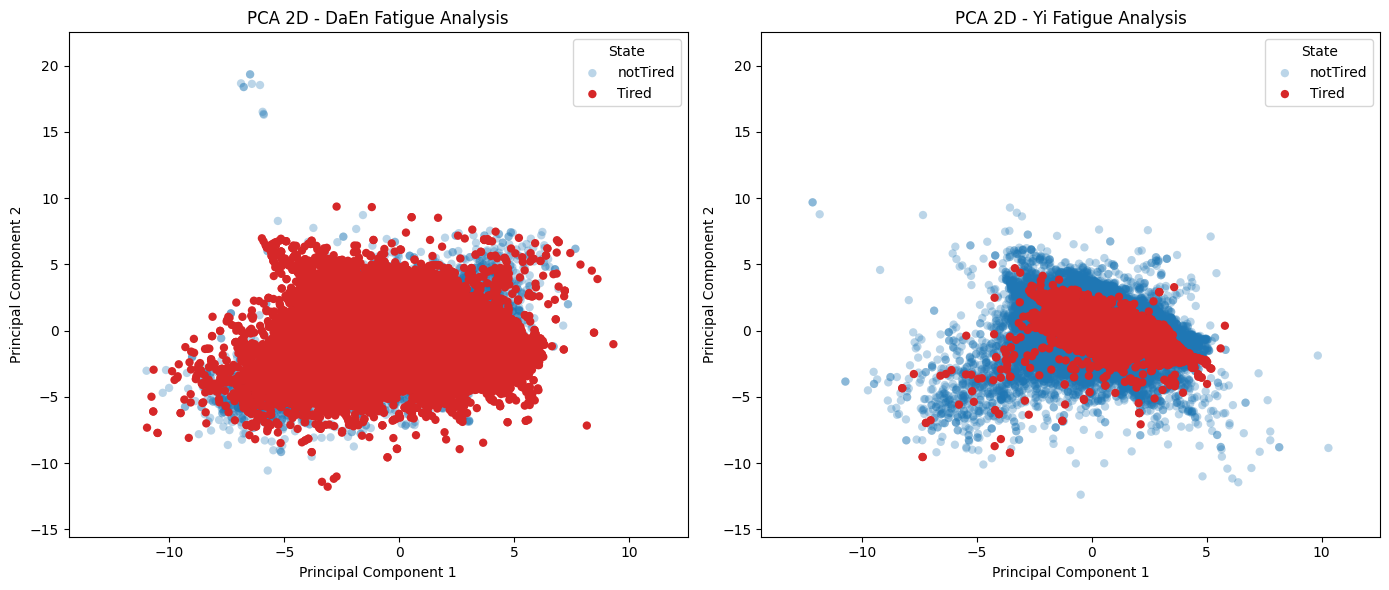

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 定義資料讀取函數
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    if not os.path.exists(folder_path):
        print(f"警告：找不到路徑 {folder_path}")
        return pd.DataFrame()
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            
            if 'notTired' in file_name:
                state_label = 'notTired'
            elif 'Tired' in file_name:
                state_label = 'Tired'
            else:
                continue
            
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            combined_data.append(df)
            
    if combined_data:
        return pd.concat(combined_data, ignore_index=True)
    else:
        return pd.DataFrame()

# ==========================================
# 2. 載入與整合數據
# ==========================================
path_A = '../data_v58/test_data' 
path_B = './test_data_hengling_yi'

df_A = load_data_from_folder(path_A, 'DaEn')
df_B = load_data_from_folder(path_B, 'Yi')
df_all = pd.concat([df_A, df_B], ignore_index=True)

feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']
df_all = df_all.dropna(subset=feature_cols)
X = df_all[feature_cols]

# ==========================================
# 3. 資料標準化
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. 執行 PCA 降維
# ==========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_all['PCA1'] = X_pca[:, 0]
df_all['PCA2'] = X_pca[:, 1]

# ==========================================
# 5. 計算統一的坐標軸範圍
# ==========================================
x_min, x_max = df_all['PCA1'].min(), df_all['PCA1'].max()
y_min, y_max = df_all['PCA2'].min(), df_all['PCA2'].max()
x_margin = (x_max - x_min) * 0.1
y_margin = (y_max - y_min) * 0.1
xlim_set = (x_min - x_margin, x_max + x_margin)
ylim_set = (y_min - y_margin, y_max + y_margin)

# ==========================================
# 6. 視覺化繪圖 (完美實現老師的 Alpha 分流邏輯)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
custom_palette = {'notTired': '#1f77b4', 'Tired': '#d62728'} # 藍色與紅色

# ------------------------------------------
# 圖一：單獨繪製 DaEn (Training Set)
# ------------------------------------------
ax1 = axes[0]
df_daen = df_all[df_all['Student'] == 'DaEn']
# DaEn 的狀況：notTired (藍色) 數量較少被壓在下面 -> 設為完全不透明 (alpha=1.0) 並後畫，讓它浮上來
df_daen_not_tired = df_daen[df_daen['State'] == 'notTired']
ax1.scatter(df_daen_not_tired['PCA1'], df_daen_not_tired['PCA2'], 
            color=custom_palette['notTired'], alpha=0.3, edgecolor='none', label='notTired')
# DaEn 的狀況：Tired (紅色) 鋪天蓋地，會覆蓋別人 -> 設為超透明 (alpha=0.3)
df_daen_tired = df_daen[df_daen['State'] == 'Tired']
ax1.scatter(df_daen_tired['PCA1'], df_daen_tired['PCA2'], 
            color=custom_palette['Tired'], alpha=1.0, edgecolor='none', label='Tired')



ax1.set_title('PCA 2D - DaEn Fatigue Analysis')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.set_xlim(xlim_set)
ax1.set_ylim(ylim_set)
ax1.legend(title='State')

# ------------------------------------------
# 圖二：單獨繪製 Yi (Test Set)
# ------------------------------------------
ax2 = axes[1]
df_yi = df_all[df_all['Student'] == 'Yi']

# Yi 的狀況：notTired (藍色) 鋪天蓋地，會覆蓋別人 -> 設為超透明 (alpha=0.3)
df_yi_not_tired = df_yi[df_yi['State'] == 'notTired']
ax2.scatter(df_yi_not_tired['PCA1'], df_yi_not_tired['PCA2'], 
            color=custom_palette['notTired'], alpha=0.3, edgecolor='none', label='notTired')

# Yi 的狀況：Tired (紅色) 只有稀疏幾點 -> 設為完全不透明 (alpha=1.0) 確保能被看見
df_yi_tired = df_yi[df_yi['State'] == 'Tired']
ax2.scatter(df_yi_tired['PCA1'], df_yi_tired['PCA2'], 
            color=custom_palette['Tired'], alpha=1.0, edgecolor='none', label='Tired')

ax2.set_title('PCA 2D - Yi Fatigue Analysis')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_xlim(xlim_set)
ax2.set_ylim(ylim_set)
ax2.legend(title='State')

plt.tight_layout()
plt.show()

In [6]:
import os
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# ==========================================
# 1. 定義資料讀取函數
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    if not os.path.exists(folder_path):
        print(f"警告：找不到路徑 {folder_path}")
        return pd.DataFrame()
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            
            if 'notTired' in file_name:
                state_label = 'notTired'
            elif 'Tired' in file_name:
                state_label = 'Tired'
            else:
                continue
            
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            combined_data.append(df)
            
    if combined_data:
        return pd.concat(combined_data, ignore_index=True)
    else:
        return pd.DataFrame()

# ==========================================
# 2. 載入與整合數據
# ==========================================
path_A = '../data_v58/test_data' 
path_B = './test_data_hengling_yi'

df_A = load_data_from_folder(path_A, 'DaEn')
df_B = load_data_from_folder(path_B, 'Yi')
df_all = pd.concat([df_A, df_B], ignore_index=True)

feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']
df_all = df_all.dropna(subset=feature_cols)
X = df_all[feature_cols]

# ==========================================
# 3. 資料標準化
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. 執行 PCA 降維 (保留 5 個主成分)
# ==========================================
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# 將 5 個主成分全數存回 DataFrame (改命名為方便迴圈讀取的欄位)
df_all['PC1'] = X_pca[:, 0]
df_all['PC2'] = X_pca[:, 1]
df_all['PC3'] = X_pca[:, 2]
df_all['PC4'] = X_pca[:, 3]
df_all['PC5'] = X_pca[:, 4]

# 印出解釋變異量供報告參考
print("=== 各主成分解釋變異量 ===")
for i in range(5):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.2%}")
print("==========================")

# ==========================================
# 5. 確保儲存目錄存在
# ==========================================
output_dir = "./pca_html"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"\n📂 已自動建立資料夾：{output_dir}")

# ==========================================
# 6. 定義要嘗試的所有 3D 三軸組合 (包含 2+3+4 等)
# ==========================================
combinations_to_try = [
    ('PC1', 'PC2', 'PC3'),
    ('PC1', 'PC2', 'PC4'),
    ('PC1', 'PC2', 'PC5'),
    ('PC1', 'PC3', 'PC4'),
    ('PC1', 'PC3', 'PC5'),
    ('PC2', 'PC3', 'PC4'),  # 👈 你特別指定的 2+3+4 組合
    ('PC2', 'PC3', 'PC5'),
    ('PC3', 'PC4', 'PC5')
]

print("\n🚀 開始批次製作 Plotly 3D 互動網頁...")

for x_col, y_col, z_col in combinations_to_try:
    # 建立檔名後綴，例如 "2+3+4"
    combo_suffix = f"{x_col[-1]}+{y_col[-1]}+{z_col[-1]}"
    
    # ------------------------------------------
    # (1) 繪製 DaEn (Training Set)
    # ------------------------------------------
    df_daen = df_all[df_all['Student'] == 'DaEn'].copy()
    # 排序確保不透明的點 (notTired) 後畫，浮在最上層
    df_daen['sort_order'] = df_daen['State'].map({'Tired': 0, 'notTired': 1})
    df_daen = df_daen.sort_values('sort_order')
    
    fig_daen = px.scatter_3d(
        df_daen, x=x_col, y=y_col, z=z_col,
        color='State',
        color_discrete_map={'notTired': '#1f77b4', 'Tired': '#d62728'},
        title=f"PCA 3D ({combo_suffix}) - DaEn Fatigue Analysis (Training Set)",
        labels={x_col: x_col, y_col: y_col, z_col: z_col}
    )
    # 套用老師的非對稱透明度 (Tired=0.3, notTired=1.0) 且修正 line 邊框
    fig_daen.update_traces(marker=dict(size=2.5, line=dict(width=0)), selector=dict(name='Tired'), opacity=0.3)
    fig_daen.update_traces(marker=dict(size=3, line=dict(width=0)), selector=dict(name='notTired'), opacity=1.0)
    
    file_path_daen = os.path.join(output_dir, f"pca_3d_{combo_suffix}_daen.html")
    fig_daen.write_html(file_path_daen)
    print(f"  └─ 已儲存: {file_path_daen}")
    
    # ------------------------------------------
    # (2) 繪製 Yi (Test Set: 横嶺山)
    # ------------------------------------------
    df_yi = df_all[df_all['Student'] == 'Yi'].copy()
    # 排序確保不透明的點 (Tired) 後畫，浮在最上層
    df_yi['sort_order'] = df_yi['State'].map({'notTired': 0, 'Tired': 1})
    df_yi = df_yi.sort_values('sort_order')
    
    fig_yi = px.scatter_3d(
        df_yi, x=x_col, y=y_col, z=z_col,
        color='State',
        color_discrete_map={'notTired': '#1f77b4', 'Tired': '#d62728'},
        title=f"PCA 3D ({combo_suffix}) - Yi Fatigue Analysis (Test Set)",
        labels={x_col: x_col, y_col: y_col, z_col: z_col}
    )
    # 套用老師的非對稱透明度 (notTired=0.3, Tired=1.0) 且修正 line 邊框
    fig_yi.update_traces(marker=dict(size=2.5, line=dict(width=0)), selector=dict(name='notTired'), opacity=0.3)
    fig_yi.update_traces(marker=dict(size=3, line=dict(width=0)), selector=dict(name='Tired'), opacity=1.0)
    
    file_path_yi = os.path.join(output_dir, f"pca_3d_{combo_suffix}_yi.html")
    fig_yi.write_html(file_path_yi)
    print(f"  └─ 已儲存: {file_path_yi}")

print(f"\n🎉 恭喜！全數 8 種組合（共 16 個網頁）已成功生成至 {output_dir} 資料夾內。")

=== 各主成分解釋變異量 ===
PC1: 26.84%
PC2: 20.65%
PC3: 17.94%
PC4: 14.38%
PC5: 12.04%

🚀 開始批次製作 Plotly 3D 互動網頁...
  └─ 已儲存: ./pca_html/pca_3d_1+2+3_daen.html
  └─ 已儲存: ./pca_html/pca_3d_1+2+3_yi.html
  └─ 已儲存: ./pca_html/pca_3d_1+2+4_daen.html
  └─ 已儲存: ./pca_html/pca_3d_1+2+4_yi.html
  └─ 已儲存: ./pca_html/pca_3d_1+2+5_daen.html
  └─ 已儲存: ./pca_html/pca_3d_1+2+5_yi.html
  └─ 已儲存: ./pca_html/pca_3d_1+3+4_daen.html
  └─ 已儲存: ./pca_html/pca_3d_1+3+4_yi.html
  └─ 已儲存: ./pca_html/pca_3d_1+3+5_daen.html
  └─ 已儲存: ./pca_html/pca_3d_1+3+5_yi.html
  └─ 已儲存: ./pca_html/pca_3d_2+3+4_daen.html
  └─ 已儲存: ./pca_html/pca_3d_2+3+4_yi.html
  └─ 已儲存: ./pca_html/pca_3d_2+3+5_daen.html
  └─ 已儲存: ./pca_html/pca_3d_2+3+5_yi.html
  └─ 已儲存: ./pca_html/pca_3d_3+4+5_daen.html
  └─ 已儲存: ./pca_html/pca_3d_3+4+5_yi.html

🎉 恭喜！全數 8 種組合（共 16 個網頁）已成功生成至 ./pca_html 資料夾內。


In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# ==========================================
# 1. 定義資料讀取函數
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    if not os.path.exists(folder_path):
        print(f"警告：找不到路徑 {folder_path}")
        return pd.DataFrame()
        
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(folder_path, file_name)
            df = pd.read_csv(file_path)
            
            if 'notTired' in file_name:
                state_label = 'notTired'
            elif 'Tired' in file_name:
                state_label = 'Tired'
            else:
                continue
            
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            combined_data.append(df)
            
    if combined_data:
        return pd.concat(combined_data, ignore_index=True)
    else:
        return pd.DataFrame()

# ==========================================
# 2. 載入與整合數據
# ==========================================
path_A = '../data_v58/test_data' 
path_B = './test_data_hengling_yi'

df_A = load_data_from_folder(path_A, 'DaEn')
df_B = load_data_from_folder(path_B, 'Yi')
df_all = pd.concat([df_A, df_B], ignore_index=True)

feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']
df_all = df_all.dropna(subset=feature_cols)
X = df_all[feature_cols]

# ==========================================
# 3. 資料標準化
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 4. 執行 PCA 降維 (保留 5 個主成分)
# ==========================================
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

df_all['PC1'] = X_pca[:, 0]
df_all['PC2'] = X_pca[:, 1]
df_all['PC3'] = X_pca[:, 2]
df_all['PC4'] = X_pca[:, 3]
df_all['PC5'] = X_pca[:, 4]

# ==========================================
# 5. 確保儲存目錄存在
# ==========================================
output_dir = "./pca_html_add"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"\n📂 已自動建立資料夾：{output_dir}")

# ==========================================
# 6. 使用 Plotly 生成兩人合併對比的 3D 網頁檔
# ==========================================
# 定義欲實驗的所有 3D 三軸組合
combinations_to_try = [
    ('PC1', 'PC2', 'PC3'),
    ('PC1', 'PC2', 'PC4'),
    ('PC1', 'PC2', 'PC5'),
    ('PC2', 'PC3', 'PC4'),
    ('PC3', 'PC4', 'PC5')
]

# 精心設計的 4 類配色 (使用同色系但深淺不同的原則)
# 精神飽滿 (notTired) 一律偏藍色系 / 疲勞 (Tired) 一律偏紅色系
color_map = {
    'DaEn_notTired': '#4A90E2',  # 天藍色
    'DaEn_Tired':    '#D0021B',  # 正紅色
    'Yi_notTired':   '#1F3A60',  # 深海藍
    'Yi_Tired':      '#FF6B6B'   # 珊瑚紅 (淡紅)
}

print("\n🚀 開始製作兩人合併對比的 Plotly 3D 互動網頁...")

for x_col, y_col, z_col in combinations_to_try:
    combo_suffix = f"{x_col[-1]}+{y_col[-1]}+{z_col[-1]}"
    
    # 複製一份資料進行排序，控制圖層疊加順序
    df_plot = df_all.copy()
    
    # 排序規則：大面積、會覆蓋別人的類別先畫(sort_order小)，少數關鍵點後畫(sort_order大)
    # 這裡讓 DaEn_Tired 和 Yi_notTired 先畫(底層)，其餘浮在上層
    layer_map = {
        'DaEn_Tired': 0, 
        'Yi_notTired': 1, 
        'DaEn_notTired': 2, 
        'Yi_Tired': 3
    }
    df_plot['sort_order'] = df_plot['Combined_Label'].map(layer_map)
    df_plot = df_plot.sort_values('sort_order')
    
    # 建立合併後的 3D 圖表
    fig = px.scatter_3d(
        df_plot, x=x_col, y=y_col, z=z_col,
        color='Combined_Label',
        color_discrete_map=color_map,
        title=f"PCA 3D Comparison ({combo_suffix}) - DaEn vs Yi",
        labels={x_col: x_col, y_col: y_col, z_col: z_col}
    )
    
    # 根據老師的指導原則，分別指定 4 個類別的透明度與大小
    # (1) 大面積的底層資料點設為半透明 (opacity=0.3)
    fig.update_traces(marker=dict(size=2.5, line=dict(width=0)), selector=dict(name='DaEn_Tired'), opacity=0.3)
    fig.update_traces(marker=dict(size=2.5, line=dict(width=0)), selector=dict(name='Yi_notTired'), opacity=0.3)
    
    # (2) 稀少、容易被壓住的點設為完全不透明 (opacity=1.0)
    fig.update_traces(marker=dict(size=3, line=dict(width=0)), selector=dict(name='DaEn_notTired'), opacity=1.0)
    fig.update_traces(marker=dict(size=3, line=dict(width=0)), selector=dict(name='Yi_Tired'), opacity=1.0)
    
    # 儲存至指定的 pca_html 資料夾中
    file_path = os.path.join(output_dir, f"pca_3d_{combo_suffix}_comparison.html")
    fig.write_html(file_path)
    print(f"  └─ 已儲存合併對比檔: {file_path}")

print(f"\n🎉 合併圖表全部製作完畢！已成功儲存至 {output_dir} 內。")


📂 已自動建立資料夾：./pca_html_add

🚀 開始製作兩人合併對比的 Plotly 3D 互動網頁...
  └─ 已儲存合併對比檔: ./pca_html_add/pca_3d_1+2+3_comparison.html
  └─ 已儲存合併對比檔: ./pca_html_add/pca_3d_1+2+4_comparison.html
  └─ 已儲存合併對比檔: ./pca_html_add/pca_3d_1+2+5_comparison.html
  └─ 已儲存合併對比檔: ./pca_html_add/pca_3d_2+3+4_comparison.html
  └─ 已儲存合併對比檔: ./pca_html_add/pca_3d_3+4+5_comparison.html

🎉 合併圖表全部製作完畢！已成功儲存至 ./pca_html_add 內。


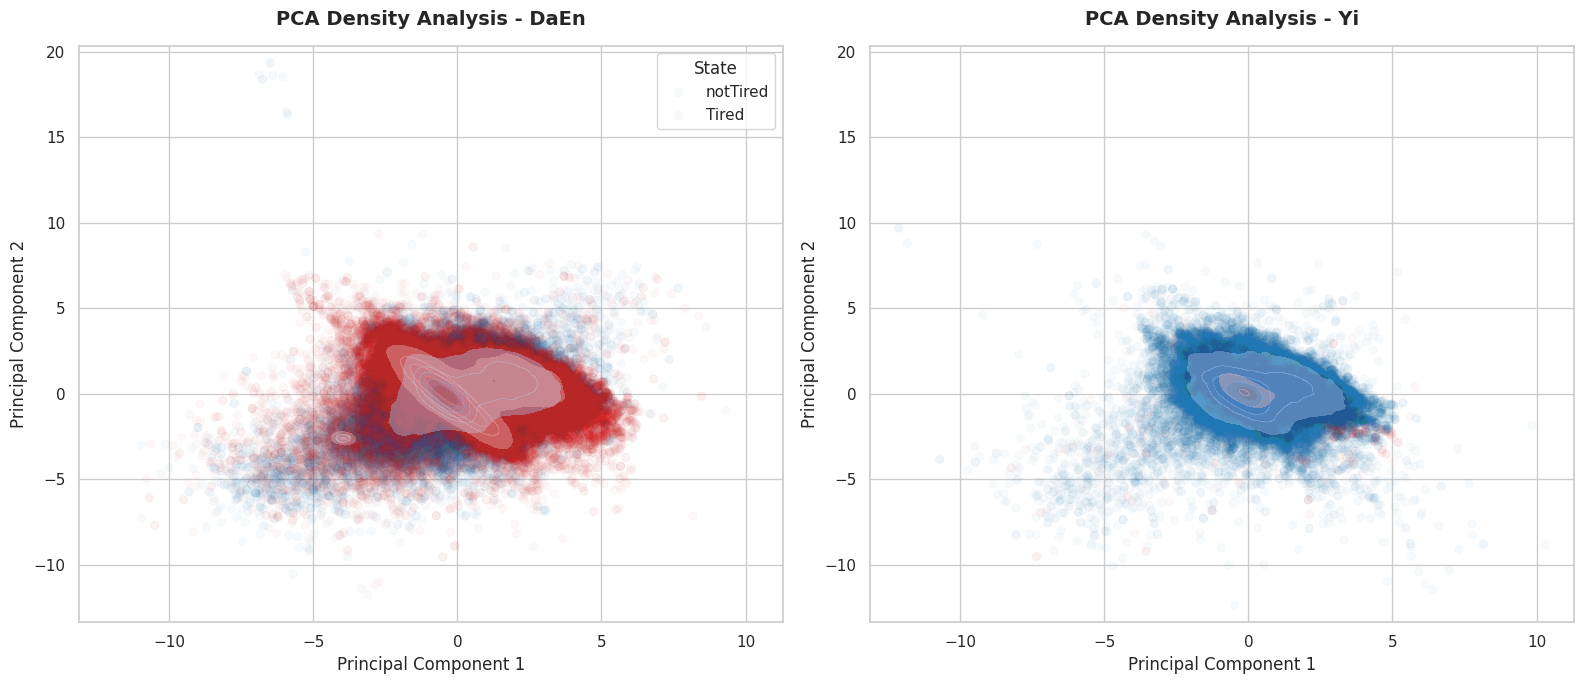

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1 到 4 部分：資料讀取、標準化與 PCA (維持不變)
# ==========================================
def load_data_from_folder(folder_path, student_label):
    combined_data = []
    if not os.path.exists(folder_path): return pd.DataFrame()
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            df = pd.read_csv(os.path.join(folder_path, file_name))
            if 'notTired' in file_name: state_label = 'notTired'
            elif 'Tired' in file_name: state_label = 'Tired'
            else: continue
            df['Student'] = student_label
            df['State'] = state_label
            df['Combined_Label'] = f"{student_label}_{state_label}"
            combined_data.append(df)
    return pd.concat(combined_data, ignore_index=True) if combined_data else pd.DataFrame()

path_A = '../data_v58/test_data' 
path_B = './test_data_hengling_yi'
df_all = pd.concat([load_data_from_folder(path_A, 'DaEn'), load_data_from_folder(path_B, 'Yi')], ignore_index=True)
feature_cols = ['acceleration_X', 'acceleration_Y', 'acceleration_Z', 'gyroscope_X', 'gyroscope_Y', 'gyroscope_Z']
df_all = df_all.dropna(subset=feature_cols)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_all[feature_cols])

pca = PCA(n_components=2) # 轉為 2D 以進行高精確度密度分析
X_pca = pca.fit_transform(X_scaled)
df_all['PC1'] = X_pca[:, 0]
df_all['PC2'] = X_pca[:, 1]

# ==========================================
# 5. 終極解決混雜：繪製邊際分佈曲線圖 (Joint Distribution)
# ==========================================
# 換回靜態模式，確保輸出精美圖片
%matplotlib inline

# 設定 Seaborn 風格，讓圖表更具學術質感
sns.set_theme(style="whitegrid")

# 調整畫布：左右並排，看清兩人「各自內部」的疲勞核心密度
fig = plt.figure(figsize=(16, 7))
custom_palette = {'notTired': '#1f77b4', 'Tired': '#d62728'}

# ------------------------------------------
# (1) 評審必懂：使用帶有邊際分佈的二維核密度估計圖
# ------------------------------------------
# 這裡我們直接用更直觀的繪圖方式來呈現
for i, student in enumerate(['DaEn', 'Yi']):
    df_sub = df_all[df_all['Student'] == student]
    
    # 建立子圖
    ax = fig.add_subplot(1, 2, i+1)
    
    # 畫上淡淡的散佈點當背景 (alpha=0.05 降到極低，不干擾視線)
    sns.scatterplot(
        data=df_sub, x='PC1', y='PC2', hue='State', 
        palette=custom_palette, alpha=0.03, edgecolor=None, ax=ax, legend=(i==0)
    )
    
    # 關鍵：加上「等高線核密度估計 (KDE)」
    # fill=True 會像氣象圖一樣填滿核心區域，levels=8 代表密度的層級
    sns.kdeplot(
        data=df_sub, x='PC1', y='PC2', hue='State', 
        palette=custom_palette, fill=True, alpha=0.4, levels=6, thresh=0.1, ax=ax, legend=False
    )
    
    ax.set_title(f"PCA Density Analysis - {student}", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    
    # 統一鎖定軸範圍，方便左右互看比較
    ax.set_xlim(df_all['PC1'].min()-1, df_all['PC1'].max()+1)
    ax.set_ylim(df_all['PC2'].min()-1, df_all['PC2'].max()+1)

plt.tight_layout()
plt.show()